# **Space Weather Project | Code for SPOCA 171A Active Region Masks**

Workflow

*   Write all SPOCA masks + 171A EUV images to local drive of 1 month
*   Manually compare these masks with HARPS on JHelioviewer
*   Introduce GOES flaring data
*   Duplicate the flaring AR's parameters in the dataset to obtain a 50/50 flaring/no-flaring dataset.
*   Use random forest to determine feature importance
*   Compare obtained feature importance, with the new features, to the SHARP feature importance
*   Report on the results in teams when completed


# initialisation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install drms sunpy[all] reproject aiapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.0/191.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.8/379.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 971.6/971.6 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
import os
import cv2
import drms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import pandas as pd
from sunpy.net import Fido, attrs as a
from astropy.io import fits
import sunpy.map
from reproject import reproject_interp
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy import ndimage
from skimage import measure
from imageio import imread
from skimage.measure import label, regionprops, shannon_entropy
from skimage.transform import resize
from scipy.ndimage import sobel
from scipy.spatial.distance import cdist

In [ ]:
# Image Configuration ─────────────────────────────────────────────────────────────
IMG_SIZE = 512  # depending on speed can be increased to 4k or decreased to 256

# 1) Write all SPOCA masks + 171A EUV images to local drive of 1 month

##Load SPOCA Data

Make sure you have the folder of 171A images in your drive (https://mega.nz/file/1Dg0iaAA#0ZRzdon9F7j0jiCjWHfUh-JNoxw5zfcmzceKrh_VySo)

In [ ]:
BASE_PATH = "/content/drive/MyDrive/171"

img_path  = os.path.join(BASE_PATH, "171_test", "imgs")
train_mask_path = os.path.join(BASE_PATH, "171_train", "171(spoca)", "masks")
test_mask_path = os.path.join(BASE_PATH, "171_test", "masks(spoca)")

print(train_mask_path)
print(test_mask_path)

/content/drive/MyDrive/171/171_train/171(spoca)/masks
/content/drive/MyDrive/171/171_test/masks(spoca)


In [ ]:
train_masks = sorted(os.listdir(train_mask_path))
test_masks = sorted(os.listdir(test_mask_path))

print("Number of training masks:", len(train_masks))
print("Number of test masks (full year 2016):", len(test_masks))

Number of training masks: 4364
Number of test masks (full year 2016): 360


## Definitions for the masks and 171A AIA images


In [ ]:
def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

def load_dataset(img_dir, mask_dir):
    images = []
    masks = []

    img_files = sorted(os.listdir(img_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in tqdm(zip(img_files, mask_files)):
        img = load_image(os.path.join(img_dir, img_file))
        mask = load_image(os.path.join(mask_dir, mask_file))

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [ ]:
def show_overlay(img, mask):
    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.3)  # overlay
    plt.title("Mask on Image Example")
    plt.axis('off')
    plt.show()

### Example / Test

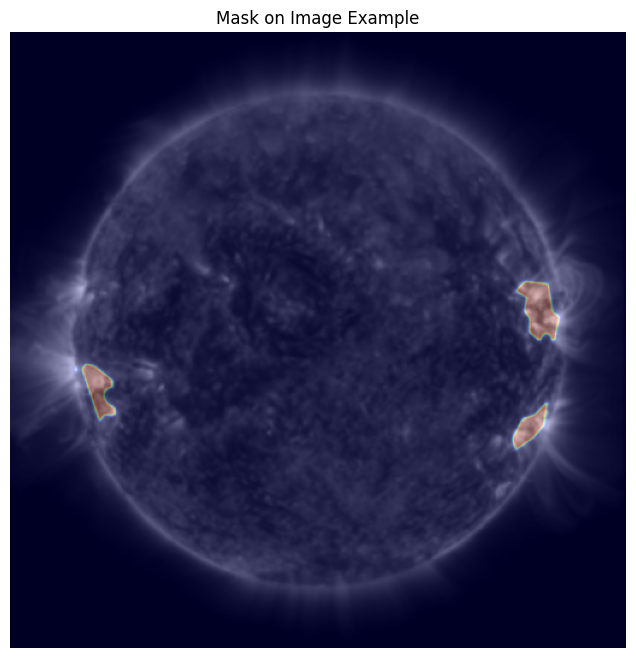

In [ ]:
# Jan 1 2016
img = load_image(os.path.join(img_path, test_masks[0]))
mask = load_image(os.path.join(test_mask_path, test_masks[0]))

show_overlay(img, mask)

## Write 1 month of images to local drive

In [ ]:
def save_overlay(img, mask, output_path):
    """
    Overlays a mask on an image and saves the result to a file.
    """
    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.3)  # overlay
    plt.title(f"Overlaid Image: {os.path.basename(output_path)}")
    plt.axis('off')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close()


### Define the month

In [ ]:
# Change target month!-------------------------------------------------------------------------------------
target_month = '06'

# Create an output inside 171 folder
output_dir = os.path.join(BASE_PATH, f"overlaid_images_{target_month}")
os.makedirs(output_dir, exist_ok=True)

print(f"Processing images for month: {target_month}")
print(f"Saving overlaid images to: {output_dir}")

# Get all available image filenames from the image directory
all_image_filenames = sorted(os.listdir(img_path))

processed_count = 0
for filename in tqdm(all_image_filenames):
    # Extract the month string from the filename (e.g., '2016_01_01...')
    # Assuming filename format: YYYY_MM_DD__HH_MM_SS_MS__SDO_AIA_AIA_171.png
    # The month is typically at index 1 if split by '_'
    try:
        month_str = filename.split('_')[1]
    except IndexError:
        print(f"Could not parse month from filename: {filename}. Skipping.")
        continue

    if month_str == target_month:
        img_file_full_path = os.path.join(img_path, filename)
        mask_file_full_path = os.path.join(test_mask_path, filename) # Assuming masks have same filenames

        if os.path.exists(img_file_full_path) and os.path.exists(mask_file_full_path):
            # Load the image and mask using the previously defined load_image function
            img = load_image(img_file_full_path)
            mask = load_image(mask_file_full_path)

            output_file_path = os.path.join(output_dir, filename)
            save_overlay(img, mask, output_file_path)
            processed_count += 1
        else:
            print(f"Skipping {filename}: corresponding image or mask file not found.")

print(f"Finished processing. Saved {processed_count} overlaid images for month {target_month}.")


Processing images for month: 06
Saving overlaid images to: /content/drive/MyDrive/171/overlaid_images_06


100%|██████████| 360/360 [00:24<00:00, 14.82it/s]

Finished processing. Saved 30 overlaid images for month 06.


# 2) import selected active regions

## Merge obtained data into 1 csv and import here

Below is an example code for only the data from June. I added the file in the 171 folder so BASE_PATH stays the same. I have then added the folder "masks(spoca)_06updated" inside the test folder such that its path is "/content/drive/MyDrive/171/171_test/masks(spoca)_06updated".

In [ ]:
csv_path = os.path.join("/content/drive/MyDrive/150AR_identity.csv") #Change when completing code------------------------------------------------------
df = pd.read_csv(csv_path, sep=",")

# Safety check
#print(df.columns)

# Extract columns
HARPNUM = df["HARPNUM"].values
NAOO_AR = df["AR"].values
time = df["Date"].astype(str) + " " + df["Time"].astype(str)

# Safety check
print("HARPNUM:", HARPNUM[:10])
print("NAOO_AR:", NAOO_AR[:10])
print("time:", time[:10])

HARPNUM: ['6585' '6591' '6576' '6591' '0' '0' '0' '0' '0' '6599']
NAOO_AR: [12549 12550 12551 12550     0     0     0     0     0 12552]
time: 0    2016-06-01 22:59:46
1    2016-06-01 22:59:46
2    2016-06-01 22:59:46
3    2016-06-02 22:59:58
4    2016-06-03 22:59:46
5    2016-06-04 23:00:10
6    2016-06-05 23:00:10
7    2016-06-06 23:00:10
8    2016-06-07 23:00:10
9    2016-06-08 23:00:10
dtype: object


Note that I have included 0 if there's no NAOO active region on that day.

# 3) Introduce GOES flaring data for each active region by NOAA number

In [ ]:
# Code for importing all flaring data for the AR in CSV file
def get_goes_flares(start: str, end: str, noaa_list=None) -> pd.DataFrame:
    """
    Fetch GOES flare data using SunPy HEK.

    Parameters
    ----------
    start, end : str
        Date range (e.g. '2016-06-01')
    noaa_list : array-like, optional
        Filter flares to only these NOAA AR numbers

    Returns
    -------
    pd.DataFrame with:
        - event_starttime (datetime)
        - fl_goescls (e.g. 'M1.2')
        - ar_noaanum (int)
        - flare_class (C/M/X)
        - FLARE_LABEL (0/1)
    """

    # Normalize date format
    start = start.replace('.', '-')
    end   = end.replace('.', '-')

    # Query HEK (GOES flares)
    result = Fido.search(
        a.Time(start, end),
        a.hek.EventType('FL'),
        a.hek.OBS.Observatory == "GOES"
    )

    if len(result) == 0:
        return pd.DataFrame()

    table = result['hek']

    # Keep columns where each row has a single value
    valid_cols = [col for col in table.colnames if table[col].ndim <= 1]
    table = table[valid_cols]

    df = table.to_pandas()

    # Import only flare time, scale and AR number
    cols = ['event_starttime', 'fl_goescls', 'ar_noaanum']
    df = df[[c for c in cols if c in df.columns]].copy()

    # Drop missing AR numbers if needed
    df = df.dropna(subset=['ar_noaanum'])

    # Convert types
    df['ar_noaanum'] = df['ar_noaanum'].astype(int)
    df['event_starttime'] = pd.to_datetime(df['event_starttime'], utc=True)

    # Extract flare class (C/M/X) + binary classification
    df['flare_class'] = df['fl_goescls'].astype(str).str[0]
    df['FLARE_LABEL'] = df['flare_class'].isin(['C', 'M', 'X']).astype(int)
    n_flares = (df['FLARE_LABEL'] == 1).sum()
    n_non_flares = (df['FLARE_LABEL'] == 0).sum()
    print(f"Flaring events: {n_flares}")
    print(f"Non-flaring events: {n_non_flares}")

    # Filter on the active regions present in our CSV
    if noaa_list is not None:
        df = df[df['ar_noaanum'].isin(noaa_list)]

    return df.reset_index(drop=True)

NameError: name 'pd' is not defined

In [ ]:
# Using the function above and importing the flaring data

flares = get_goes_flares(
    start="2016-06-01",
    end="2016-08-30",   # Adjust for full dataset---------------------------------------------
    noaa_list=NAOO_AR
)

# Safety check
#print(flares.head())

Flaring events: 97
Non-flaring events: 218


# 4) extract HMI magnetic data


In [ ]:
# JSOC client
client = drms.Client(email="robbe.elsen@student.kuleuven.be")

def extract_ar_features(
    time_obs,
    harpnum,
    mask_path,
    save_dir="/content/drive/MyDrive/magnetogram_data",
    plot=False
):


    # 1. Download HMI magnetogram
    query = f"hmi.M_720s[{time_obs}]"

    export = client.export(
        query,
        protocol="fits",
        method="url"
    )

    export.wait()

    os.makedirs(save_dir, exist_ok=True)

    files = export.download(save_dir)

    mag_file = files['download'].iloc[0]

    # 2. Load HMI data
    mag_map = sunpy.map.Map(mag_file)
    hmi_data = mag_map.data

    # 3. Load SPOCA mask
    mask_256 = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    if mask_256 is None:
        raise ValueError(f"Could not load mask: {mask_path}")

    mask_256 = mask_256 / 255.0

    # 4. Resize mask to 4096x4096
    mask_4096 = cv2.resize(
        mask_256,
        (4096, 4096),
        interpolation=cv2.INTER_NEAREST
    )

    # Binary mask
    mask_4096 = mask_4096 > 0

    # 5. Apply mask to HMI
    masked_hmi = np.where(
        mask_4096,
        hmi_data,
        np.nan
    )

    # 6. Crop active region
    ys, xs = np.where(mask_4096 > 0)

    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    cropped_hmi = masked_hmi[
        ymin:ymax,
        xmin:xmax
    ]

    # Optional plot just to check
    if plot:

        plt.figure(figsize=(6,6))

        plt.imshow(
            cropped_hmi,
            cmap="gray",
            vmin=-500,
            vmax=500
        )

        plt.title(f"HARPNUM {harpnum}")

        plt.axis("off")

        plt.colorbar(label="B [Gauss]")

        plt.show()

    # 7. Remove NaNs
    pixels = cropped_hmi[np.isfinite(cropped_hmi)]

    # Safety check
    if len(pixels) == 0:
        raise ValueError("No valid magnetic pixels found.")


    # 8. Feature extraction

    # Mean magnetic field
    mean_B = np.mean(pixels)

    # Max magnetic field
    max_B = np.max(pixels)

    # Min magnetic field
    min_B = np.min(pixels)

    # Magnetic variability
    std_B = np.std(pixels)

    # Positive polarity
    positive_flux = np.sum(
        pixels[pixels > 0]
    )

    # Negative polarity
    negative_flux = np.sum(
        np.abs(pixels[pixels < 0])
    )

    # Polarity mixing
    polarity_mixing = (
        positive_flux - negative_flux
    )

    # Polarity separation
    pos_y, pos_x = np.where(cropped_hmi > 0)
    neg_y, neg_x = np.where(cropped_hmi < 0)

    if len(pos_x) > 0 and len(neg_x) > 0:

        pos_center = np.array([
            np.mean(pos_y),
            np.mean(pos_x)
        ])

        neg_center = np.array([
            np.mean(neg_y),
            np.mean(neg_x)
        ])

        polarity_separation = np.linalg.norm(
            pos_center - neg_center
        )

    else:

        polarity_separation = np.nan

    # Magnetic field gradient
    grad_x = sobel(
        np.nan_to_num(cropped_hmi),
        axis=1
    )

    grad_y = sobel(
        np.nan_to_num(cropped_hmi),
        axis=0
    )

    gradient_magnitude = np.sqrt(
        grad_x**2 + grad_y**2
    )

    mean_gradient = np.nanmean(
        gradient_magnitude
    )

    # Magnetic energy proxy
    magnetic_energy = np.nansum(
        cropped_hmi**2
    )

    # Return dictionary
    features = {

        "HARPNUM": harpnum,
        "time": time_obs,

        "mean_B": mean_B,
        "max_B": max_B,
        "min_B": min_B,
        "std_B": std_B,

        "positive_flux": positive_flux,
        "negative_flux": negative_flux,

        "polarity_mixing": polarity_mixing,
        "polarity_separation": polarity_separation,

        "mean_gradient": mean_gradient,

        "magnetic_energy": magnetic_energy
    }

    return features

In [ ]:
"""
# Load CSV
input_path = "/content/drive/MyDrive/150AR_identity.csv"
df = pd.read_csv(input_path)
"""

# Folder containing masks
mask_folder = "/content/drive/MyDrive/171/updated_masks_060708"

# Store extracted features
all_features = []

for idx, row in df.iterrows():

    try:
        # Build timestamp
        time_obs = f"{row['Date']}T{row['Time']}"

        # HARPNUM
        harpnum = int(row["HARPNUM"])

        # Build filename
        mask_filename = row["SPOCA_mask"] + ".png"

        # Full path
        mask_path = os.path.join(mask_folder, mask_filename)

        # Skip invalid HARPNUM if desired
        if harpnum == 0:
            print(f"Skipping row {idx} (HARPNUM=0)")
            all_features.append({})
            continue

        # Extract features
        features = extract_ar_features(
            time_obs=time_obs,
            harpnum=harpnum,
            mask_path=mask_path,
            plot=False
        )

        # Optional metadata
        features["time_obs"] = time_obs
        features["mask_path"] = mask_path

        all_features.append(features)

        print(f"Done row {idx}")

    except Exception as e:

        print(f"Failed row {idx}: {e}")

        all_features.append({})

# Convert to dataframe
features_df = pd.DataFrame(all_features)

# Merge with original CSV
final_df = pd.concat([df, features_df], axis=1)

# Save final CSV
output_path = "/content/drive/MyDrive/ar_features_completed.csv"

final_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Failed row 0: 'SPOCA_mask'
Failed row 1: 'SPOCA_mask'
Failed row 2: 'SPOCA_mask'
Failed row 3: 'SPOCA_mask'
Failed row 4: 'SPOCA_mask'
Failed row 5: 'SPOCA_mask'
Failed row 6: 'SPOCA_mask'
Failed row 7: 'SPOCA_mask'
Failed row 8: 'SPOCA_mask'
Failed row 9: 'SPOCA_mask'
Failed row 10: 'SPOCA_mask'
Failed row 11: 'SPOCA_mask'
Failed row 12: 'SPOCA_mask'
Failed row 13: 'SPOCA_mask'
Failed row 14: 'SPOCA_mask'
Failed row 15: 'SPOCA_mask'
Failed row 16: 'SPOCA_mask'
Failed row 17: 'SPOCA_mask'
Failed row 18: 'SPOCA_mask'
Failed row 19: 'SPOCA_mask'
Failed row 20: 'SPOCA_mask'
Failed row 21: 'SPOCA_mask'
Failed row 22: 'SPOCA_mask'
Failed row 23: 'SPOCA_mask'
Failed row 24: 'SPOCA_mask'
Failed row 25: 'SPOCA_mask'
Failed row 26: 'SPOCA_mask'
Failed row 27: 'SPOCA_mask'
Failed row 28: 'SPOCA_mask'
Failed row 29: 'SPOCA_mask'
Failed row 30: 'SPOCA_mask'
Failed row 31: 'SPOCA_mask'
Failed row 32: 'SPOCA_mask'
Failed row 33: 'SPOCA_mask'
Failed row 34: 'SPOCA_mask'
Failed row 35: 'SPOCA_mask'
Fa

In [ ]:
# Load CSV
input_csv = "/content/drive/MyDrive/hmi_features_completed.csv"

df = pd.read_csv(input_csv)

# Columns you WANT to keep
columns_to_keep = [
    "HARPNUM",
    "time",
    "mean_B",
    "max_B",
    "min_B",
    "std_B",
    "positive_flux",
    "negative_flux",
    "polarity_mixing",
    "polarity_separation",
    "mean_gradient",
    "magnetic_energy"
]

# Create smaller dataframe
new_df = df[columns_to_keep]

# Remove rows with only 1 non-NaN value
new_df = new_df.dropna(thresh=2)

# Remove rows where all numeric values are 0
numeric_cols = new_df.select_dtypes(include='number').columns

new_df = new_df[
    (new_df[numeric_cols] != 0).any(axis=1)
]

# Save new CSV
new_df.to_csv("/content/drive/MyDrive/only_hmi_features.csv",index=False)

print("Saved")

Saved


# 5) Extract 171A EUV data using the images + SPOCA mask

In [ ]:
# Adjusted SPOCA masks to only contain the active regions detected by NOAA
updated_mask_path = "/content/drive/MyDrive/171/171_test/updated_masks_060708" #Adjust for complete dataset --------------------------------------

Define 171A features.

Note: check entropy, reasoning unclear

In [ ]:
MIN_REGION_PX = 5   # Guess

def extract_euv_features(img, mask, min_region_px=MIN_REGION_PX):
    """
    Extract morphological and intensity features from a 171Å EUV image
    using its SPOCA active-region mask.

    Parameters
    ----------
    img : 2-D ndarray (float, normalised 0–1)
        171Å image, same spatial resolution as the mask.
    mask : 2-D ndarray
        SPOCA mask; thresholded to bool internally (threshold = 0.5).
    min_region_px : int
        Regions smaller than this are ignored.

    Returns
    -------
    list of dict – one entry per detected active region.
    """

    binary  = (mask > 0.5).astype(np.uint8)           # Remove intermediate float values
    labelled = label(binary)
    regions  = regionprops(labelled, intensity_image=img)

    results = []
    for props in regions:

        if props.area < min_region_px:
            continue

        # ── Morphological features ────────────────────────────────────────────
        area      = props.area           # number of pixels belonging to the AR
        perimeter = props.perimeter      # boundary length in pixels

        # Aspect ratio: major / minor axis of the equivalent fitted ellipse
        minor        = props.minor_axis_length
        aspect_ratio = props.major_axis_length / minor if minor > 0 else np.nan

        # Solidity: fragmentation of active region: area / convex-hull area
        #   → 1.0  = perfectly convex (compact)
        #   → < 1  = fragmented / concave boundary
        solidity = props.solidity

        # Circularity (shape index): 4π·A / Permiter²
        #   → 1.0  = perfect circle
        #   → → 0  = highly irregular
        circularity = (4 * np.pi * area / perimeter ** 2
                       if perimeter > 0 else np.nan)

        # ── Intensity features (restricted to the AR pixel footprint) ─────────
        ar_pixels = img[props.coords[:, 0], props.coords[:, 1]]  # 1-D array

        mean_intensity = float(np.mean(ar_pixels))
        max_intensity  = float(np.max(ar_pixels))
        min_intensity  = float(np.min(ar_pixels))
        contrast       = max_intensity - min_intensity

        # Entropy: Shannon entropy of the AR pixel-intensity distribution.
        #   Measures how spread-out (heterogeneous) intensities are across the AR.
        #   Higher entropy → more complex / varied intensity structure.
        #   Computed on the raw pixel values (not a 2-D patch), so background pixels from the bounding box are excluded.

        # Methodology needs to be verified, as I currently do not understand it
        entropy = float(shannon_entropy(ar_pixels))

        results.append({
            "label"          : props.label,
            "area"           : area,
            "perimeter"      : perimeter,
            "aspect_ratio"   : aspect_ratio,
            "solidity"       : solidity,
            "circularity"    : circularity,
            "mean_intensity" : mean_intensity,
            "max_intensity"  : max_intensity,
            "min_intensity"  : min_intensity,
            "contrast"       : contrast,
            "entropy"        : entropy,
        })

    return results

Compute parameters

In [ ]:
csv_path = os.path.join("/content/drive/MyDrive/150AR_identity.csv") #Change when completing code------------------------------------------------------
df = pd.read_csv(csv_path, sep=",")


all_euv_features = []

feature_names = [
    "label",
    "area",
    "perimeter",
    "aspect_ratio",
    "solidity",
    "circularity",
    "mean_intensity",
    "max_intensity",
    "min_intensity",
    "contrast",
    "entropy"
]

for i in tqdm(range(len(df))):

    try:
        # Skip entries without NOAA AR
        if NAOO_AR[i] == 0:
            continue

        filename_raw = df["SPOCA_mask"].iloc[i]

        # Skip missing or bad entries
        if pd.isna(filename_raw):
            continue

        filename = str(filename_raw).strip() + ".png"

        img_file  = os.path.join(img_path, filename)
        mask_file = os.path.join(updated_mask_path, filename)

        if not os.path.exists(img_file) or not os.path.exists(mask_file):
            continue

        # Load data
        img  = load_image(img_file)
        mask = load_image(mask_file)

        regions = extract_euv_features(img, mask)

        # Loop over regions, add label to define which region
        for region_features in regions:

            region_features["HARPNUM"] = HARPNUM[i]
            region_features["NOAA_AR"] = NAOO_AR[i]
           # region_features["time"] = time[i]

            all_euv_features.append(region_features)

    except Exception as e:
        print(f"Error at index {i}: {e}")
        continue


# Convert to DataFrame
df_euv = pd.DataFrame(all_euv_features)

print("\nExtraction complete.")
print("Number of feature rows:", len(df_euv))

# Preview
display(df_euv.head())

# Save results
output_path = os.path.join(BASE_PATH, "euv_features.csv")
df_euv.to_csv(output_path, index=False)

print(f"\nSaved EUV features to:\n{output_path}")




100%|██████████| 155/155 [00:01<00:00, 93.76it/s]


Extraction complete.
Number of feature rows: 31


,label,area,perimeter,aspect_ratio,solidity,circularity,mean_intensity,max_intensity,min_intensity,contrast,entropy,HARPNUM,NOAA_AR
0,1,182.0,60.627417,2.877777,0.900990,0.622219,0.746111,0.968627,0.505882,0.462745,6.205202,6591,12550
1,1,411.0,116.568542,2.200381,0.686144,0.380092,0.495100,0.925490,0.266667,0.658824,6.732253,6599,12552
2,1,530.0,100.225397,1.202083,0.850722,0.663025,0.528206,0.850980,0.278431,0.572549,6.634585,6599,12552
3,1,643.0,124.710678,1.283067,0.774699,0.519533,0.664428,0.996078,0.356863,0.639216,6.849575,6613,12553
4,1,242.0,68.526912,1.777833,0.812081,0.647594,0.631275,0.941176,0.423529,0.517647,6.524443,6613,12553



Saved EUV features to:
/content/drive/MyDrive/171/euv_features.csv


In [ ]:
# Load CSV
input_csv = "/content/drive/MyDrive/171/euv_features.csv"

df = pd.read_csv(input_csv)

# Columns you WANT to keep
columns_to_keep = [
    "area",
    "perimeter",
    "aspect_ratio",
    "solidity",
    "circularity",
    "mean_intensity",
    "max_intensity",
    "min_intensity",
    "contrast",
    "entropy",
    "HARPNUM",
    "NOAA_AR"
]

# Create smaller dataframe
new_df = df[columns_to_keep]

# Remove rows with only 1 non-NaN value
new_df = new_df.dropna(thresh=2)

# Remove rows where all numeric values are 0
numeric_cols = new_df.select_dtypes(include='number').columns

new_df = new_df[
    (new_df[numeric_cols] != 0).any(axis=1)
]

# Save new CSV
new_df.to_csv("/content/drive/MyDrive/only_euv_features.csv",index=False)

print("Saved")

Saved


# 6) combine everything

now we have 2 .csv files with features from hmi and 171A, now were going to match them

In [ ]:
# Load CSVs
hmi_df = pd.read_csv("/content/drive/MyDrive/only_hmi_features.csv")
euv_df = pd.read_csv("/content/drive/MyDrive/only_euv_features.csv")

# Clean datatypes
hmi_df["HARPNUM"] = hmi_df["HARPNUM"].astype(str)
euv_df["HARPNUM"] = euv_df["HARPNUM"].astype(str)

# Merge columns
merged_df = pd.merge(
    hmi_df,
    euv_df,
    on=["HARPNUM"],
    how="left"
)

merged_df = merged_df.dropna()

# Save
output_path = "/content/drive/MyDrive/merged_features.csv"

merged_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/merged_features.csv


 and add flaring data

In [ ]:
# Load your merged dataset
df = pd.read_csv(
    "/content/drive/MyDrive/merged_features.csv"
)

# Get all flare events
flare_df = get_goes_flares(
    start="2016-06-01",
    end="2016-08-30",
    noaa_list=df["NOAA_AR"].unique()
)

# Function to determine strongest flare
def strongest_flare(classes):

    priority = {
        "A": 1,
        "B": 2,
        "C": 3,
        "M": 4,
        "X": 5
    }

    strongest = "None"
    strongest_value = 0

    for flare in classes:

        flare = str(flare)

        if flare in priority:

            if priority[flare] > strongest_value:

                strongest = flare
                strongest_value = priority[flare]

    return strongest

# Compute strongest flare per NOAA AR
flare_summary = (
    flare_df
    .groupby("ar_noaanum")["flare_class"]
    .apply(strongest_flare)
    .to_dict()
)

# Add flare class column
df["flare_class"] = df["NOAA_AR"].map(flare_summary)

# Replace missing values
df["flare_class"] = df["flare_class"].fillna("None")

# Save final dataset
output_path = "/content/drive/MyDrive/final_dataset.csv"

df.to_csv(output_path, index=False)

print("Saved:", output_path)

Flaring events: 97
Non-flaring events: 218
Saved: /content/drive/MyDrive/final_dataset.csv


# 7) Feature importance

Final steps are in a new notebook:

https://colab.research.google.com/drive/1kCWst9omPAR0ZP_IlaOWmw9WjkHLBxr5?usp=sharing
